In [ ]:
%%capture
!pip install mediapipe opencv-python-headless huggingface_hub hf_transfer tqdm pandas

In [ ]:
USE_DRIVE = True   # ← set False to skip Drive

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/ASL_Project'
else:
    BASE_DIR = '/content/ASL_Project'

import os
DATASET_DIR  = os.path.join(BASE_DIR, 'dataset')
LANDMARK_DIR = os.path.join(BASE_DIR, 'landmarks')

os.makedirs(DATASET_DIR,  exist_ok=True)
os.makedirs(LANDMARK_DIR, exist_ok=True)

print(f'Dataset  → {DATASET_DIR}')
print(f'Landmarks→ {LANDMARK_DIR}')

Mounted at /content/drive
Dataset  → /content/drive/MyDrive/ASL_Project/dataset
Landmarks→ /content/drive/MyDrive/ASL_Project/landmarks


In [ ]:
import os
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '1'   # faster downloads

from huggingface_hub import snapshot_download

print('⬇️  Downloading dataset — this may take a few minutes...')

snapshot_download(
    repo_id   = 'akasheroor/American-Sign-Language-Dataset',
    repo_type = 'dataset',
    allow_patterns = ['part_1/**'],   # only part_1
    local_dir = DATASET_DIR,
    local_dir_use_symlinks = False,
)

print('✅ Download complete!')

# Show class folders
part1_path = os.path.join(DATASET_DIR, 'part_1')
classes = sorted(os.listdir(part1_path))
print(f'\nFound {len(classes)} classes:')
print(classes)

⬇️  Downloading dataset — this may take a few minutes...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching ... files: 0it [00:00, ?it/s]

HTTP Error 429 thrown while requesting HEAD https://huggingface.co/datasets/akasheroor/American-Sign-Language-Dataset/resolve/e7979505c0dff7072ef36d45b3cddfffb50ba871/part_1/06693975886056691-HAWAII.mp4
Rate limited. Waiting 27.0s before retry [Retry 1/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/datasets/akasheroor/American-Sign-Language-Dataset/resolve/e7979505c0dff7072ef36d45b3cddfffb50ba871/part_1/06695172262113935-SAD.mp4
Rate limited. Waiting 27.0s before retry [Retry 1/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/datasets/akasheroor/American-Sign-Language-Dataset/resolve/e7979505c0dff7072ef36d45b3cddfffb50ba871/part_1/0669594529530173-LOSE%20GAME.mp4
Rate limited. Waiting 27.0s before retry [Retry 1/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/datasets/akasheroor/American-Sign-Language-Dataset/resolve/e7979505c0dff7072ef36d45b3cddfffb50ba871/part_1/06697558113247015-HEADPHONES.mp4
Rate limited. Waiting

KeyboardInterrupt: 

In [ ]:
import pathlib

video_exts = {'.mp4', '.avi', '.mov', '.webm', '.mkv'}
all_videos = list(pathlib.Path(DATASET_DIR).rglob('*'))
all_videos = [p for p in all_videos if p.suffix.lower() in video_exts]

print(f"Videos on disk: {len(all_videos)}")
if all_videos:
    print(f"Example: {all_videos[0]}")
    # Extract class names from filenames like "06693975886056691-HAWAII.mp4"
    classes = set(v.stem.split('-', 1)[1] for v in all_videos if '-' in v.stem)
    print(f"Unique sign classes: {len(classes)}")
    print(sorted(classes)[:15])

Videos on disk: 7839
Example: /content/drive/MyDrive/ASL_Project/dataset/part_1/12320108203648461-SPIDER.mp4
Unique sign classes: 2040
['1 DOLLAR', '5 DOLLARS', '8 HOUR', '9 OCLOCK', 'A LITTLE BIT', 'ABBREVIATE', 'ABOVE', 'ABSOLUTELY NOTHING', 'ACCENT', 'ACCEPT', 'ACCESS', 'ACCIDENT', 'ACCOMPLISH', 'ACCORDION', 'ACCOUNTANT']


In [ ]:
import mediapipe as mp
import pkgutil

print("Top-level mp attributes:")
print([x for x in dir(mp) if not x.startswith('_')])

print("\nSubmodules:")
for pkg in pkgutil.walk_packages(mp.__path__, prefix=mp.__name__+'.'):
    print(pkg.name)

Top-level mp attributes:
['Image', 'ImageFormat', 'tasks']

Submodules:
mediapipe.tasks
mediapipe.tasks.c
mediapipe.tasks.c.libmediapipe
mediapipe.tasks.python
mediapipe.tasks.python.audio
mediapipe.tasks.python.audio.audio_classifier
mediapipe.tasks.python.audio.core
mediapipe.tasks.python.audio.core.audio_record
mediapipe.tasks.python.audio.core.audio_task_running_mode
mediapipe.tasks.python.benchmark
mediapipe.tasks.python.benchmark.benchmark_utils
mediapipe.tasks.python.benchmark.vision
mediapipe.tasks.python.benchmark.vision.benchmark
mediapipe.tasks.python.benchmark.vision.core
mediapipe.tasks.python.benchmark.vision.core.base_vision_benchmark_api
mediapipe.tasks.python.components
mediapipe.tasks.python.components.containers
mediapipe.tasks.python.components.containers.audio_data
mediapipe.tasks.python.components.containers.audio_data_c
mediapipe.tasks.python.components.containers.bounding_box
mediapipe.tasks.python.components.containers.category
mediapipe.tasks.python.components

In [ ]:
import urllib.request, os

MODEL_DIR = '/content/models'
os.makedirs(MODEL_DIR, exist_ok=True)

models = {
    'pose_landmarker.task':  'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task',
    'face_landmarker.task':  'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task',
    'hand_landmarker.task':  'https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task',
}

for fname, url in models.items():
    path = os.path.join(MODEL_DIR, fname)
    if os.path.exists(path):
        print(f'✅ Already exists: {fname}')
    else:
        print(f'⬇️  Downloading {fname}...')
        urllib.request.urlretrieve(url, path)
        print(f'✅ Done: {fname}')

⬇️  Downloading pose_landmarker.task...
✅ Done: pose_landmarker.task
⬇️  Downloading face_landmarker.task...
✅ Done: face_landmarker.task
⬇️  Downloading hand_landmarker.task...
✅ Done: hand_landmarker.task


In [ ]:
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from pathlib import Path
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

print(f"MediaPipe version: {mp.__version__}")

# ── Detect actual landmark counts from a test frame ────────
# Face landmarker v2 returns 478 landmarks (468 + 10 iris)
# We detect this automatically instead of hardcoding

def make_pose_detector():
    opts = mp_vision.PoseLandmarkerOptions(
        base_options=mp_python.BaseOptions(
            model_asset_path='/content/models/pose_landmarker.task'),
        running_mode=mp_vision.RunningMode.IMAGE,
        num_poses=1,
        min_pose_detection_confidence=0.5,
        min_pose_presence_confidence=0.5,
        min_tracking_confidence=0.5,
        output_segmentation_masks=False,
    )
    return mp_vision.PoseLandmarker.create_from_options(opts)

def make_face_detector():
    opts = mp_vision.FaceLandmarkerOptions(
        base_options=mp_python.BaseOptions(
            model_asset_path='/content/models/face_landmarker.task'),
        running_mode=mp_vision.RunningMode.IMAGE,
        num_faces=1,
        min_face_detection_confidence=0.5,
        min_face_presence_confidence=0.5,
        min_tracking_confidence=0.5,
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=False,
    )
    return mp_vision.FaceLandmarker.create_from_options(opts)

def make_hand_detector():
    opts = mp_vision.HandLandmarkerOptions(
        base_options=mp_python.BaseOptions(
            model_asset_path='/content/models/hand_landmarker.task'),
        running_mode=mp_vision.RunningMode.IMAGE,
        num_hands=2,
        min_hand_detection_confidence=0.5,
        min_hand_presence_confidence=0.5,
        min_tracking_confidence=0.5,
    )
    return mp_vision.HandLandmarker.create_from_options(opts)

# ── Auto-detect face landmark count ────────────────────────

def detect_face_lm_count(face_det, test_video):
    """Run face detector on one frame to get actual landmark count."""
    cap = cv2.VideoCapture(str(test_video))
    count = 478  # safe default (478 = 468 mesh + 10 iris)
    while True:
        ret, frame = cap.read()
        if not ret: break
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        result = face_det.detect(mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb))
        if result.face_landmarks:
            count = len(result.face_landmarks[0])
            print(f"✅ Face landmarks detected: {count}")
            break
    cap.release()
    return count

# ── Landmark extraction (fixed-size, zeros when not detected) ─

POSE_DIM  = 33 * 4    # 132
HAND_DIM  = 21 * 3    # 63  (per hand)
# FACE_DIM set after auto-detection below

def get_pose(result):
    if result.pose_landmarks:
        return np.array([[lm.x, lm.y, lm.z, lm.visibility]
                         for lm in result.pose_landmarks[0]],
                        dtype=np.float32).flatten()
    return np.zeros(POSE_DIM, dtype=np.float32)

def get_face(result, face_dim):
    if result.face_landmarks:
        lms = result.face_landmarks[0]
        arr = np.array([[lm.x, lm.y, lm.z]
                        for lm in lms], dtype=np.float32).flatten()
        # Pad or truncate to fixed size (handles 468 vs 478 variation)
        if len(arr) < face_dim:
            arr = np.pad(arr, (0, face_dim - len(arr)))
        else:
            arr = arr[:face_dim]
        return arr
    return np.zeros(face_dim, dtype=np.float32)

def get_hands(result):
    left  = np.zeros(HAND_DIM, dtype=np.float32)
    right = np.zeros(HAND_DIM, dtype=np.float32)
    if result.hand_landmarks:
        for i, hand_lms in enumerate(result.hand_landmarks):
            arr = np.array([[lm.x, lm.y, lm.z]
                            for lm in hand_lms], dtype=np.float32).flatten()
            label = result.handedness[i][0].category_name
            if label == 'Left':  left  = arr
            else:                right = arr
    return left, right

def frame_to_vector(rgb_frame, pose_det, face_det, hand_det, face_dim):
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
    pose_r = pose_det.detect(mp_img)
    face_r = face_det.detect(mp_img)
    hand_r = hand_det.detect(mp_img)
    left, right = get_hands(hand_r)
    return np.concatenate([
        get_pose(pose_r),
        get_face(face_r, face_dim),
        left,
        right
    ])

def process_video(video_path, pose_det, face_det, hand_det, face_dim):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened(): return None
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret: break
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_to_vector(rgb, pose_det, face_det, hand_det, face_dim))
    cap.release()
    return np.stack(frames, axis=0) if frames else None

print("✅ Functions defined. Now creating detectors...")

pose_det = make_pose_detector()
face_det = make_face_detector()
hand_det = make_hand_detector()

# Auto-detect face landmark count from first video
SRC = Path(DATASET_DIR) / 'part_1'
VIDEO_EXTS = {'.mp4', '.avi', '.mov', '.webm', '.mkv'}
all_videos = [p for p in SRC.rglob('*') if p.suffix.lower() in VIDEO_EXTS]

FACE_LM_COUNT = detect_face_lm_count(face_det, all_videos[0])
FACE_DIM      = FACE_LM_COUNT * 3
FEATURE_DIM   = POSE_DIM + FACE_DIM + HAND_DIM + HAND_DIM

print(f"\nFinal feature dimensions:")
print(f"  Pose  : {POSE_DIM}  (33 × 4)")
print(f"  Face  : {FACE_DIM}  ({FACE_LM_COUNT} × 3)")
print(f"  L hand: {HAND_DIM}  (21 × 3)")
print(f"  R hand: {HAND_DIM}  (21 × 3)")
print(f"  TOTAL : {FEATURE_DIM}")

MediaPipe version: 0.10.32
✅ Functions defined. Now creating detectors...
✅ Face landmarks detected: 478

Final feature dimensions:
  Pose  : 132  (33 × 4)
  Face  : 1434  (478 × 3)
  L hand: 63  (21 × 3)
  R hand: 63  (21 × 3)
  TOTAL : 1692


Video : 12320108203648461-SPIDER.mp4
Class : SPIDER
Creating fresh detectors...

Detection rate across 170 frames:
  Pose detected : 170/170 frames
  Face detected : 170/170 frames
  Hands detected: 30/170 frames

Sample annotated frames (every 10th):
Frame 1/170


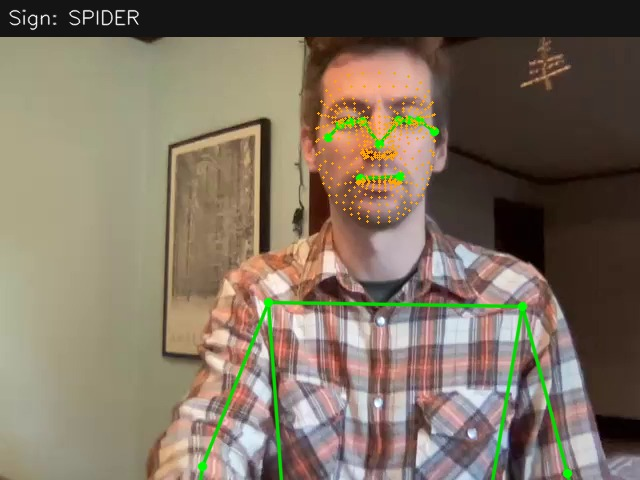

Frame 35/170


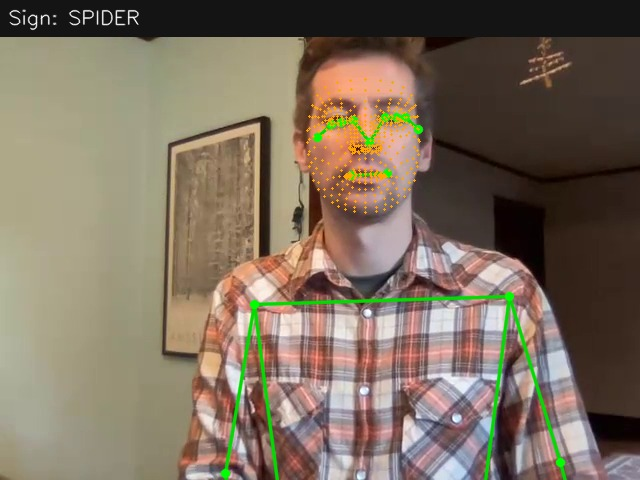

Frame 69/170


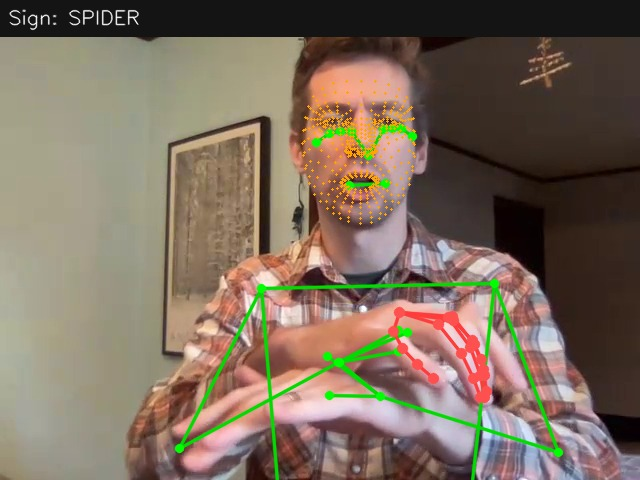

Frame 103/170


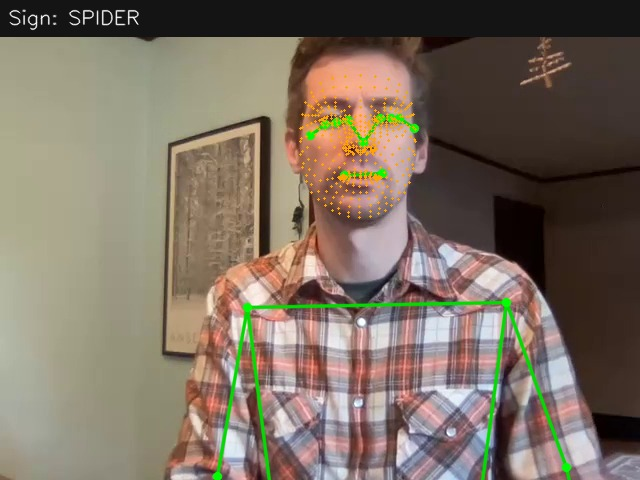

Frame 137/170


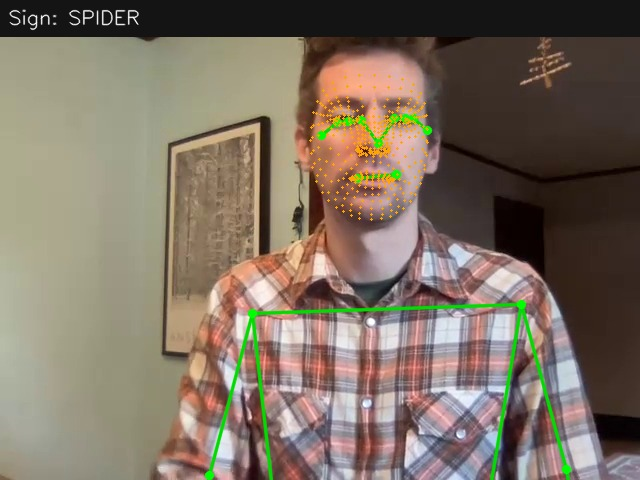


✅ Video → /content/asl_mediapipe_overlay.mp4
✅ GIF   → /content/asl_mediapipe_overlay.gif
✅ h264  → /content/asl_overlay_h264.mp4

COMMITTING TO GITHUB


In [ ]:
# ============================================================
# FIXED DEMO — overlay with guaranteed landmark drawing
# ============================================================

import cv2, numpy as np, mediapipe as mp, subprocess, os, base64
from pathlib import Path
from IPython.display import HTML, display

# ── CONFIG ──────────────────────────────────────────────────
GITHUB_REPO  = "bencejdanko/sign-language-translation"
NOTEBOOK_NAME = "DATA_255_ASL_MediaPipe_Preprocessing.ipynb"
COMMIT_MSG   = "Add ASL MediaPipe preprocessing demo notebook"
OUTPUT_VIDEO = "/content/asl_mediapipe_overlay.mp4"
OUTPUT_GIF   = "/content/asl_mediapipe_overlay.gif"

def get_label(video_path):
    return Path(video_path).stem.split('-', 1)[1]

demo_video = all_videos[0]
demo_label = get_label(demo_video)
print(f"Video : {demo_video.name}")
print(f"Class : {demo_label}")

POSE_CONNECTIONS = [
    (11,12),(11,13),(13,15),(12,14),(14,16),
    (11,23),(12,24),(23,24),
    (23,25),(25,27),(24,26),(26,28),
    (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),
    (9,10),(15,17),(15,19),(15,21),(16,18),(16,20),(16,22)
]
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),(0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),(0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),(5,9),(9,13),(13,17)
]

def draw_all(frame, pose_r, face_r, hand_r):
    ann = frame.copy()
    h, w = ann.shape[:2]

    # Pose — green
    if pose_r.pose_landmarks:
        lms = pose_r.pose_landmarks[0]
        pts = [(int(lm.x * w), int(lm.y * h)) for lm in lms]
        for a, b in POSE_CONNECTIONS:
            if a < len(pts) and b < len(pts):
                cv2.line(ann, pts[a], pts[b], (0, 220, 0), 2, cv2.LINE_AA)
        for pt in pts:
            cv2.circle(ann, pt, 4, (0, 255, 0), -1, cv2.LINE_AA)

    # Face — amber/orange dots
    if face_r.face_landmarks:
        for lm in face_r.face_landmarks[0]:
            px, py = int(lm.x * w), int(lm.y * h)
            cv2.circle(ann, (px, py), 1, (0, 165, 255), -1)

    # Hands — red
    if hand_r.hand_landmarks:
        for hand_lms in hand_r.hand_landmarks:
            hpts = [(int(lm.x * w), int(lm.y * h)) for lm in hand_lms]
            for a, b in HAND_CONNECTIONS:
                cv2.line(ann, hpts[a], hpts[b], (60, 60, 255), 2, cv2.LINE_AA)
            for pt in hpts:
                cv2.circle(ann, pt, 5, (80, 80, 255), -1, cv2.LINE_AA)

    # Label bar
    cv2.rectangle(ann, (0, 0), (w, 36), (20, 20, 20), -1)
    cv2.putText(ann, f"Sign: {demo_label}",
                (8, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255,255,255), 1, cv2.LINE_AA)
    return ann

# ── Recreate detectors fresh (in case they were closed) ────
print("Creating fresh detectors...")
pose_det2 = make_pose_detector()
face_det2 = make_face_detector()
hand_det2 = make_hand_detector()

# ── Read frames + detect + draw in one pass ─────────────────
cap = cv2.VideoCapture(str(demo_video))
fps = cap.get(cv2.CAP_PROP_FPS) or 30
W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

OUTPUT_VIDEO = "/content/asl_mediapipe_overlay.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (W, H))

annotated_frames = []
detection_counts = {'pose': 0, 'face': 0, 'hand': 0}
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret: break

    # Convert BGR→RGB for MediaPipe
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Ensure uint8 contiguous array
    rgb = np.ascontiguousarray(rgb, dtype=np.uint8)

    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

    pose_r = pose_det2.detect(mp_img)
    face_r = face_det2.detect(mp_img)
    hand_r = hand_det2.detect(mp_img)

    # Count detections for debugging
    if pose_r.pose_landmarks:  detection_counts['pose'] += 1
    if face_r.face_landmarks:  detection_counts['face'] += 1
    if hand_r.hand_landmarks:  detection_counts['hand'] += 1

    ann = draw_all(frame, pose_r, face_r, hand_r)
    annotated_frames.append(ann)
    writer.write(ann)
    frame_idx += 1

cap.release()
writer.release()
pose_det2.close()
face_det2.close()
hand_det2.close()

total = frame_idx
print(f"\nDetection rate across {total} frames:")
print(f"  Pose detected : {detection_counts['pose']}/{total} frames")
print(f"  Face detected : {detection_counts['face']}/{total} frames")
print(f"  Hands detected: {detection_counts['hand']}/{total} frames")

# ── Show sample annotated frames inline ─────────────────────
print("\nSample annotated frames (every 10th):")
for i in range(0, len(annotated_frames), max(1, len(annotated_frames)//5)):
    frm = annotated_frames[i]
    _, buf = cv2.imencode('.jpg', frm, [cv2.IMWRITE_JPEG_QUALITY, 92])
    print(f"Frame {i+1}/{total}")
    from IPython.display import Image as IPImage
    display(IPImage(data=buf.tobytes()))

# ── Embed video inline ──────────────────────────────────────
# Re-encode with ffmpeg for better browser compatibility
import os
OUTPUT_VIDEO_H264 = "/content/asl_overlay_h264.mp4"
os.system(f"ffmpeg -y -i {OUTPUT_VIDEO} -vcodec libx264 -pix_fmt yuv420p "
          f"{OUTPUT_VIDEO_H264} -loglevel error")

video_path = OUTPUT_VIDEO_H264 if os.path.exists(OUTPUT_VIDEO_H264) else OUTPUT_VIDEO
with open(video_path, 'rb') as f:
    video_b64 = base64.b64encode(f.read()).decode()

display(HTML(f"""
<video width="500" controls autoplay loop muted style="border-radius:8px">
  <source src="data:video/mp4;base64,{video_b64}" type="video/mp4">
</video>
<p style="font-family:monospace;font-size:12px;color:#555">
  🟢 Pose &nbsp;|&nbsp; 🟠 Face mesh &nbsp;|&nbsp; 🔴 Hands &nbsp;·&nbsp;
  Sign: <b>{demo_label}</b> &nbsp;·&nbsp; {total} frames @ {fps:.0f}fps
</p>
"""))

# ── Convert to GIF + commit ─────────────────────────────────
OUTPUT_GIF = "/content/asl_mediapipe_overlay.gif"
os.system(f"ffmpeg -y -i {OUTPUT_VIDEO} "
          f"-vf 'fps=10,scale=480:-1:flags=lanczos' "
          f"-loop 0 {OUTPUT_GIF} -loglevel error")
print(f"\n✅ Video → {OUTPUT_VIDEO}")
print(f"✅ GIF   → {OUTPUT_GIF}")
print(f"✅ h264  → {OUTPUT_VIDEO_H264}")

# ── PART 2: Save notebook + commit to GitHub ────────────────

print("\n" + "="*50)
print("COMMITTING TO GITHUB")
print("="*50)


# Clone the repo (uses your Colab GitHub auth or token)
REPO_DIR = "/content/sign-language-translation"
if not os.path.exists(REPO_DIR):
    # Add your GitHub token to Colab secrets as GITHUB_TOKEN
    try:
        from google.colab import userdata
        gh_token = userdata.get('GITHUB_TOKEN')
        clone_url = f"https://{gh_token}@github.com/{GITHUB_REPO}.git"
    except Exception:
        # Fallback: will prompt for credentials
        clone_url = f"https://github.com/{GITHUB_REPO}.git"
        print("⚠️  No GITHUB_TOKEN found in Colab secrets.")
        print("    Add it: Colab left sidebar → 🔑 Secrets → GITHUB_TOKEN")

    subprocess.run(["git", "clone", clone_url, REPO_DIR], check=True)
    print(f"✅ Repo cloned → {REPO_DIR}")
else:
    subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)
    print("✅ Repo pulled (already exists)")

# Configure git identity
subprocess.run(["git", "-C", REPO_DIR, "config", "user.email", "colab@demo.com"], check=True)
subprocess.run(["git", "-C", REPO_DIR, "config", "user.name",  "Colab Demo"], check=True)
import shutil, subprocess, os, json

REPO_DIR = "/content/sign-language-translation"

# Copy overlay files into repo
shutil.copy(OUTPUT_GIF,   os.path.join(REPO_DIR, "asl_mediapipe_overlay.gif"))
shutil.copy(OUTPUT_VIDEO, os.path.join(REPO_DIR, "asl_mediapipe_overlay.mp4"))
print("✅ Overlay files copied")

# Save notebook using ipynb file directly (more reliable than _message API)
import glob

# Find the current notebook file in Colab's working directory
nb_candidates = glob.glob("/content/**/*.ipynb", recursive=True) + \
                glob.glob("/root/**/*.ipynb", recursive=True)

# Exclude the repo itself
nb_candidates = [p for p in nb_candidates if "sign-language-translation" not in p]
print(f"Found notebooks: {nb_candidates}")

if nb_candidates:
    # Pick the most recently modified one — that's the active notebook
    active_nb = max(nb_candidates, key=os.path.getmtime)
    print(f"Active notebook: {active_nb}")
    dest = os.path.join(REPO_DIR, NOTEBOOK_NAME)
    shutil.copy(active_nb, dest)
    print(f"✅ Notebook saved → {dest}")
else:
    # Fallback: download from Colab's internal API as raw JSON
    print("No .ipynb file found locally, trying Colab download...")
    os.system(f"jupyter nbconvert --to notebook "
              f"--output {os.path.join(REPO_DIR, NOTEBOOK_NAME)} "
              f"$(ls /content/*.ipynb 2>/dev/null | head -1)")

# Stage, commit, push
subprocess.run(["git", "-C", REPO_DIR, "config", "user.email", "colab@demo.com"], check=True)
subprocess.run(["git", "-C", REPO_DIR, "config", "user.name",  "Colab Demo"],  check=True)

subprocess.run(["git", "-C", REPO_DIR, "add",
                NOTEBOOK_NAME,
                "asl_mediapipe_overlay.gif",
                "asl_mediapipe_overlay.mp4"], check=True)

result = subprocess.run(
    ["git", "-C", REPO_DIR, "commit", "-m", COMMIT_MSG],
    capture_output=True, text=True
)
print(result.stdout or "Nothing new to commit")

push = subprocess.run(
    ["git", "-C", REPO_DIR, "push"],
    capture_output=True, text=True
)
if push.returncode == 0:
    print(f"\n✅ Pushed to https://github.com/{GITHUB_REPO}")
    print(f"   → {NOTEBOOK_NAME}")
    print(f"   → asl_mediapipe_overlay.gif")
    print(f"   → asl_mediapipe_overlay.mp4")
else:
    print("❌ Push failed:")
    print(push.stderr)

In [ ]:
# ── Summary ─────────────────────────────────────────────────
print(f"""
{'='*50}
  PREPROCESSING TECHNIQUES TO BE USED
{'='*50}
  1. MediaPipe Holistic   Pose + face + hand landmarks
                          per frame → {FEATURE_DIM}-dim vector
  2. Normalisation        Zero-mean / unit-variance
                          per feature across the clip
  3. Fixed-length seq     Pad (zeros) or truncate to
                          MAX_FRAMES={MAX_FRAMES} for model input
  4. Visibility masking   Flag/drop low-confidence frames
                          using pose visibility scores
  5. Label extraction     Class name from filename
                          (ID-CLASSNAME.mp4 → CLASSNAME)
{'='*50}
  Ready for model input:  ({MAX_FRAMES}, {FEATURE_DIM})  per sample
{'='*50}
""")




  PREPROCESSING TECHNIQUES TO BE USED
  1. MediaPipe Holistic   Pose + face + hand landmarks
                          per frame → 1692-dim vector
  2. Normalisation        Zero-mean / unit-variance
                          per feature across the clip
  3. Fixed-length seq     Pad (zeros) or truncate to
                          MAX_FRAMES=10 for model input
  4. Visibility masking   Flag/drop low-confidence frames
                          using pose visibility scores
  5. Label extraction     Class name from filename
                          (ID-CLASSNAME.mp4 → CLASSNAME)
  Ready for model input:  (10, 1692)  per sample



In [ ]:
# ============================================================
# DEMO — MediaPipe overlay video + commit notebook to GitHub
# ============================================================

import cv2, numpy as np, mediapipe as mp, subprocess, os, base64
from pathlib import Path
from IPython.display import HTML, display

# ── CONFIG ──────────────────────────────────────────────────
GITHUB_REPO  = "bencejdanko/sign-language-translation"
NOTEBOOK_NAME = "DATA_255_ASL_MediaPipe_Preprocessing.ipynb"
COMMIT_MSG   = "Add ASL MediaPipe preprocessing demo notebook"
OUTPUT_VIDEO = "/content/asl_mediapipe_overlay.mp4"
OUTPUT_GIF   = "/content/asl_mediapipe_overlay.gif"

# ── PART 1: Render overlay video ────────────────────────────

POSE_CONNECTIONS = [
    (11,12),(11,13),(13,15),(12,14),(14,16),
    (11,23),(12,24),(23,24),
    (23,25),(25,27),(24,26),(26,28),
    (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),
    (9,10),(15,17),(15,19),(15,21),(16,18),(16,20),(16,22)
]
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),(0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),(0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),(5,9),(9,13),(13,17)
]

def draw_all(frame, pose_r, face_r, hand_r):
    ann = frame.copy()
    h, w = ann.shape[:2]

    # Pose — green skeleton
    if pose_r.pose_landmarks:
        lms = pose_r.pose_landmarks[0]
        pts = [(int(lm.x * w), int(lm.y * h)) for lm in lms]
        for a, b in POSE_CONNECTIONS:
            if a < len(pts) and b < len(pts):
                cv2.line(ann, pts[a], pts[b], (0, 220, 0), 2, cv2.LINE_AA)
        for pt in pts:
            cv2.circle(ann, pt, 4, (0, 255, 0), -1, cv2.LINE_AA)

    # Face — amber dots
    if face_r.face_landmarks:
        for lm in face_r.face_landmarks[0]:
            px, py = int(lm.x * w), int(lm.y * h)
            cv2.circle(ann, (px, py), 1, (0, 180, 255), -1)

    # Hands — red skeleton
    if hand_r.hand_landmarks:
        for hand_lms in hand_r.hand_landmarks:
            hpts = [(int(lm.x * w), int(lm.y * h)) for lm in hand_lms]
            for a, b in HAND_CONNECTIONS:
                cv2.line(ann, hpts[a], hpts[b], (60, 60, 255), 2, cv2.LINE_AA)
            for pt in hpts:
                cv2.circle(ann, pt, 5, (80, 80, 255), -1, cv2.LINE_AA)

    # Label overlay
    cv2.rectangle(ann, (0, 0), (w, 32), (0, 0, 0), -1)
    cv2.putText(ann, f"Sign: {demo_label}  |  Pose  Face  Hands",
                (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1, cv2.LINE_AA)
    return ann

# Read original video properties
cap = cv2.VideoCapture(str(demo_video))
fps = cap.get(cv2.CAP_PROP_FPS) or 30
W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

# Write annotated video
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (W, H))

cap = cv2.VideoCapture(str(demo_video))
frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret: break
    rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    pose_r = pose_det.detect(mp_img)
    face_r = face_det.detect(mp_img)
    hand_r = hand_det.detect(mp_img)
    ann    = draw_all(frame, pose_r, face_r, hand_r)
    writer.write(ann)
    frame_count += 1
cap.release()
writer.release()
print(f"✅ Video saved → {OUTPUT_VIDEO}  ({frame_count} frames @ {fps:.0f}fps)")

# Convert to GIF (for GitHub README, mirrors existing overlay.gif)
print("Converting to GIF...")
os.system(f"ffmpeg -y -i {OUTPUT_VIDEO} -vf 'fps=10,scale=480:-1:flags=lanczos' "
          f"-loop 0 {OUTPUT_GIF} -loglevel error")
print(f"✅ GIF saved  → {OUTPUT_GIF}")

# Display inline
with open(OUTPUT_VIDEO, 'rb') as f:
    video_b64 = base64.b64encode(f.read()).decode()
display(HTML(f"""
<video width="480" controls autoplay loop muted>
  <source src="data:video/mp4;base64,{video_b64}" type="video/mp4">
</video>
<p style="font-family:monospace;font-size:12px">
  🟢 Pose skeleton &nbsp;|&nbsp; 🟠 Face mesh &nbsp;|&nbsp; 🔴 Hand connections<br>
  Sign: <b>{demo_label}</b> &nbsp;·&nbsp; {frame_count} frames &nbsp;·&nbsp; {fps:.0f} fps
</p>
"""))

# ── PART 2: Save notebook + commit to GitHub ────────────────

print("\n" + "="*50)
print("COMMITTING TO GITHUB")
print("="*50)

# Clone the repo (uses your Colab GitHub auth or token)
REPO_DIR = "/content/sign-language-translation"
if not os.path.exists(REPO_DIR):
    # Add your GitHub token to Colab secrets as GITHUB_TOKEN
    try:
        from google.colab import userdata
        gh_token = userdata.get('GITHUB_TOKEN')
        clone_url = f"https://{gh_token}@github.com/{GITHUB_REPO}.git"
    except Exception:
        # Fallback: will prompt for credentials
        clone_url = f"https://github.com/{GITHUB_REPO}.git"
        print("⚠️  No GITHUB_TOKEN found in Colab secrets.")
        print("    Add it: Colab left sidebar → 🔑 Secrets → GITHUB_TOKEN")

    subprocess.run(["git", "clone", clone_url, REPO_DIR], check=True)
    print(f"✅ Repo cloned → {REPO_DIR}")
else:
    subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)
    print("✅ Repo pulled (already exists)")

# Configure git identity
subprocess.run(["git", "-C", REPO_DIR, "config", "user.email", "colab@demo.com"], check=True)
subprocess.run(["git", "-C", REPO_DIR, "config", "user.name",  "Colab Demo"], check=True)
import shutil, subprocess, os, json

REPO_DIR = "/content/sign-language-translation"

# Copy overlay files into repo
shutil.copy(OUTPUT_GIF,   os.path.join(REPO_DIR, "asl_mediapipe_overlay.gif"))
shutil.copy(OUTPUT_VIDEO, os.path.join(REPO_DIR, "asl_mediapipe_overlay.mp4"))
print("✅ Overlay files copied")

# Save notebook using ipynb file directly (more reliable than _message API)
import glob

# Find the current notebook file in Colab's working directory
nb_candidates = glob.glob("/content/**/*.ipynb", recursive=True) + \
                glob.glob("/root/**/*.ipynb", recursive=True)

# Exclude the repo itself
nb_candidates = [p for p in nb_candidates if "sign-language-translation" not in p]
print(f"Found notebooks: {nb_candidates}")

if nb_candidates:
    # Pick the most recently modified one — that's the active notebook
    active_nb = max(nb_candidates, key=os.path.getmtime)
    print(f"Active notebook: {active_nb}")
    dest = os.path.join(REPO_DIR, NOTEBOOK_NAME)
    shutil.copy(active_nb, dest)
    print(f"✅ Notebook saved → {dest}")
else:
    # Fallback: download from Colab's internal API as raw JSON
    print("No .ipynb file found locally, trying Colab download...")
    os.system(f"jupyter nbconvert --to notebook "
              f"--output {os.path.join(REPO_DIR, NOTEBOOK_NAME)} "
              f"$(ls /content/*.ipynb 2>/dev/null | head -1)")

# Stage, commit, push
subprocess.run(["git", "-C", REPO_DIR, "config", "user.email", "colab@demo.com"], check=True)
subprocess.run(["git", "-C", REPO_DIR, "config", "user.name",  "Colab Demo"],  check=True)

subprocess.run(["git", "-C", REPO_DIR, "add",
                NOTEBOOK_NAME,
                "asl_mediapipe_overlay.gif",
                "asl_mediapipe_overlay.mp4"], check=True)

result = subprocess.run(
    ["git", "-C", REPO_DIR, "commit", "-m", COMMIT_MSG],
    capture_output=True, text=True
)
print(result.stdout or "Nothing new to commit")

push = subprocess.run(
    ["git", "-C", REPO_DIR, "push"],
    capture_output=True, text=True
)
if push.returncode == 0:
    print(f"\n✅ Pushed to https://github.com/{GITHUB_REPO}")
    print(f"   → {NOTEBOOK_NAME}")
    print(f"   → asl_mediapipe_overlay.gif")
    print(f"   → asl_mediapipe_overlay.mp4")
else:
    print("❌ Push failed:")
    print(push.stderr)

✅ Video saved → /content/asl_mediapipe_overlay.mp4  (74 frames @ 30fps)
Converting to GIF...
✅ GIF saved  → /content/asl_mediapipe_overlay.gif



COMMITTING TO GITHUB
✅ Repo pulled (already exists)
✅ Overlay files copied
Found notebooks: ['/content/drive/MyDrive/Untitled15.ipynb', '/content/drive/MyDrive/DL_lab.ipynb', '/content/drive/MyDrive/Copy_of_LogGuardian_(1).ipynb', '/content/drive/MyDrive/Colab Notebooks/Taneja_Aashima_Homework4.ipynb', '/content/drive/MyDrive/Colab Notebooks/Taneja_HW1 (1).ipynb', '/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb', '/content/drive/MyDrive/Colab Notebooks/Taneja_HW1_source_code.ipynb', '/content/drive/MyDrive/Colab Notebooks/Taneja_HW2_source_code (1).ipynb', '/content/drive/MyDrive/Colab Notebooks/Taneja_HW3 (1).ipynb', '/content/drive/MyDrive/Colab Notebooks/Taneja_HW4 (1).ipynb', '/content/drive/MyDrive/Colab Notebooks/Taneja_HW3.ipynb', '/content/drive/MyDrive/Colab Notebooks/Taneja_HW4.ipynb', '/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb', '/content/drive/MyDrive/Colab Notebooks/Taneja_HW1.ipynb', '/content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb', '/content

In [ ]:
from google.colab import userdata
import subprocess

REPO_DIR   = "/content/sign-language-translation"
GITHUB_REPO = "bencejdanko/sign-language-translation"

# Get token from Colab secrets
try:
    gh_token = userdata.get('GITHUB_TOKEN')
    print("✅ Token loaded")
except Exception:
    gh_token = input("Paste your GitHub token (https://github.com/settings/tokens): ").strip()

# Update the remote URL to include the token
remote_url = f"https://{gh_token}@github.com/{GITHUB_REPO}.git"
subprocess.run(["git", "-C", REPO_DIR, "remote", "set-url", "origin", remote_url], check=True)

# Push
push = subprocess.run(
    ["git", "-C", REPO_DIR, "push"],
    capture_output=True, text=True
)
if push.returncode == 0:
    print(f"✅ Pushed! View at: https://github.com/{GITHUB_REPO}")
else:
    print("❌ Still failed:")
    print(push.stderr)

✅ Token loaded
✅ Pushed! View at: https://github.com/bencejdanko/sign-language-translation
